# 강원도 산불-날씨 심화 EDA: 공간 융합으로 넘어가기 위한 통계 근거

## 분석 위치
이 노트북은 `강원도-산불날씨-분석.ipynb`에서 확인한 산불 시점의 기상 이상성을 더 깊게 검정하고,
다음 단계인 `강원도-산불-날씨공간-융합EDA.ipynb`로 넘어갈 근거를 만드는 중간 분석이다.

## 분석 질문
1. 같은 기상셀, 같은 월, 같은 시간대의 비발생 대조군과 비교해도 산불 시점의 기상 조건은 통계적으로 다른가?
2. 그 기상 이상성은 `영동 해안형`, `영서 내륙형`, `고지·산간형`에서 같은 방향과 강도로 나타나는가?
3. 산불 주소가 `임야번지(산)`인지 `일반번지`인지에 따라 발화 시점의 습도, 풍속, 강수 임계치가 달라지는가?
4. 기상 신호만으로 설명되지 않는 이질성이 존재한다면, 어떤 공간/지형 변수를 다음 융합 EDA에 결합해야 하는가?

## 분석 원칙
- 결측이 있는 변수는 해당 변수 검정에서만 제외한다.
- 풍향은 산술평균하지 않고 서풍계열 여부 또는 sin/cos 파생으로만 다룬다.
- 전체 비교보다 같은 격자·월·시간대를 통제한 매칭 비교를 우선 해석한다.
- 모델링 산식 도출은 하지 않고, 시각화와 가설검정, 효과크기 중심으로 정리한다.


## 고정 순서와 색상

전체 노트북에서 기후지형유형과 번지 유형의 순서와 색상을 고정한다.

- 기후지형유형: `영동 해안형 -> 영서 내륙형 -> 고지·산간형`
- 번지 유형: `임야번지(산) -> 일반번지`
- 산불-대조군 비교: `산불 -> 매칭 비발생`


In [1]:
from pathlib import Path
from itertools import combinations
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests

try:
    from IPython.display import display, Markdown
except Exception:
    display = print

    def Markdown(text):
        return text


font_path = "C:/Windows/Fonts/malgun.ttf"
if Path(font_path).exists():
    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()
else:
    font_name = "DejaVu Sans"

sns.set_theme(
    style="whitegrid",
    font=font_name,
    rc={
        "font.family": font_name,
        "font.sans-serif": [font_name],
        "axes.unicode_minus": False,
    },
)
plt.rcParams["font.family"] = font_name
plt.rcParams["font.sans-serif"] = [font_name]
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents, Path("D:/farm-system-public-02")]:
    if (candidate / "data").exists() and (candidate / "jsw").exists():
        ROOT = candidate
        break

DATA_DIR = ROOT / "data"
WEATHER_DIR = DATA_DIR / "강원도_날씨데이터"
FIRE_DIR = DATA_DIR / "강원도_데이터"

RANDOM_STATE = 42

TYPE_ORDER = ["영동 해안형", "영서 내륙형", "고지·산간형"]
TYPE_PALETTE = {
    "영동 해안형": "#2A6FBB",
    "영서 내륙형": "#2E8B57",
    "고지·산간형": "#C97A28",
}
ADDR_ORDER = ["임야번지(산)", "일반번지"]
ADDR_PALETTE = {"임야번지(산)": "#E66101", "일반번지": "#5E3C99"}
FIRE_CONTROL_PALETTE = {"산불": "#D1495B", "매칭 비발생": "#4C78A8"}


def set_type_order(df, col="기후지형유형"):
    out = df.copy()
    if col in out.columns:
        out[col] = pd.Categorical(out[col], categories=TYPE_ORDER, ordered=True)
    return out


def set_addr_order(df, col="addr_type"):
    out = df.copy()
    if col in out.columns:
        out[col] = pd.Categorical(out[col], categories=ADDR_ORDER, ordered=True)
    return out


def savefig_show(rect=None):
    if rect is None:
        plt.tight_layout()
    else:
        plt.tight_layout(rect=rect)
    plt.show()


def format_p(p):
    if pd.isna(p):
        return "NA"
    if p < 0.001:
        return "<0.001"
    return f"{p:.3f}"


def fdr_values(p_values):
    p = pd.Series(p_values, dtype="float64")
    out = pd.Series(np.nan, index=p.index, dtype="float64")
    valid = p.notna()
    if valid.any():
        out.loc[valid] = multipletests(p.loc[valid], method="fdr_bh")[1]
    return out


def cohen_d(a, b):
    a = pd.Series(a).dropna().astype(float)
    b = pd.Series(b).dropna().astype(float)
    if len(a) < 2 or len(b) < 2:
        return np.nan
    pooled = np.sqrt(((len(a) - 1) * a.var(ddof=1) + (len(b) - 1) * b.var(ddof=1)) / (len(a) + len(b) - 2))
    if pooled == 0 or pd.isna(pooled):
        return np.nan
    return (a.mean() - b.mean()) / pooled


def cliffs_delta(a, b):
    a = pd.Series(a).dropna().astype(float)
    b = pd.Series(b).dropna().astype(float)
    if len(a) == 0 or len(b) == 0:
        return np.nan
    try:
        u = stats.mannwhitneyu(a, b, alternative="two-sided").statistic
        return (2 * u / (len(a) * len(b))) - 1
    except ValueError:
        return np.nan


def mean_ci(diff):
    diff = pd.Series(diff).dropna().astype(float)
    if len(diff) < 2:
        return np.nan, np.nan
    se = diff.std(ddof=1) / np.sqrt(len(diff))
    h = stats.t.ppf(0.975, len(diff) - 1) * se
    return diff.mean() - h, diff.mean() + h


print("ROOT:", ROOT)
print("현재 matplotlib font.family:", plt.rcParams["font.family"])
print("현재 matplotlib font.sans-serif:", plt.rcParams["font.sans-serif"][:3])


ROOT: D:\farm-system-public-02
현재 matplotlib font.family: ['Malgun Gothic']
현재 matplotlib font.sans-serif: ['Malgun Gothic']


## 1. 데이터 로드와 분석용 테이블 구성

산불 좌표를 기상 격자에 결합하고, 발생일·전일·발생시각·직전 24시간 날씨를 붙인다.
기존 기초 EDA와 동일하게 기상셀 미매칭 산불은 최근접 보정 없이 제외한다.


In [2]:
cells = pd.read_csv(WEATHER_DIR / "강원도날씨_격자.csv", encoding="utf-8-sig")
terrain = pd.read_csv(WEATHER_DIR / "강원도날씨_기후지형유형_셀분류.csv", encoding="utf-8-sig")
daily_raw = pd.read_csv(WEATHER_DIR / "강원도날씨_격자_일단위.csv", encoding="utf-8-sig")
hourly_raw = pd.read_csv(WEATHER_DIR / "강원도날씨_격자_시간단위.csv", encoding="utf-8-sig")
fire_raw = pd.read_csv(FIRE_DIR / "강원도_산불발생.csv", encoding="utf-8-sig")
grid = gpd.read_file(WEATHER_DIR / "강원도날씨_격자.geojson")

if grid.crs is None:
    grid = grid.set_crs("EPSG:4326")
else:
    grid = grid.to_crs("EPSG:4326")

terrain = set_type_order(terrain)
cells = set_type_order(cells.merge(terrain[["기상셀ID", "기후지형유형"]], on="기상셀ID", how="left"))
grid = set_type_order(grid.merge(terrain[["기상셀ID", "기후지형유형"]], on="기상셀ID", how="left"))


def add_fire_datetime(fire):
    out = fire.copy()
    out["발생일시"] = pd.to_datetime(
        dict(year=out["연도"], month=out["월"], day=out["일"], hour=out["시간"]),
        errors="coerce",
    )
    out["날짜"] = out["발생일시"].dt.normalize()
    out["전일"] = out["날짜"] - pd.Timedelta(days=1)
    out["월_key"] = out["발생일시"].dt.month
    out["시간_key"] = out["발생일시"].dt.hour
    addr = out["발생지역번지"].astype("string").fillna("").str.strip()
    out["is_mountain_address"] = addr.str.contains(r"^산", regex=True)
    out["addr_type"] = np.where(out["is_mountain_address"], "임야번지(산)", "일반번지")
    return set_addr_order(out)


def spatial_join_fire(fire, grid, terrain):
    fire = add_fire_datetime(fire)
    fire_gdf = gpd.GeoDataFrame(
        fire,
        geometry=gpd.points_from_xy(fire["경도"], fire["위도"]),
        crs="EPSG:4326",
    )
    joined = gpd.sjoin(
        fire_gdf,
        grid[["기상셀ID", "기후권역", "geometry"]],
        how="left",
        predicate="within",
    ).drop(columns=["index_right"], errors="ignore")
    unmatched = joined[joined["기상셀ID"].isna()].copy()
    matched = joined[joined["기상셀ID"].notna()].copy()
    matched = matched.merge(terrain[["기상셀ID", "기후지형유형"]], on="기상셀ID", how="left")
    matched = matched.drop(columns=["geometry"])
    return set_addr_order(set_type_order(matched)), unmatched.drop(columns=["geometry"])


def prepare_weather(daily, hourly, terrain):
    terrain_cols = terrain[["기상셀ID", "기후권역", "기후지형유형"]]

    daily = daily.copy()
    daily["날짜"] = pd.to_datetime(daily["날짜"])
    daily["월"] = daily["날짜"].dt.month
    daily["일교차_C"] = daily["최고기온_C"] - daily["최저기온_C"]
    daily["서풍계열_최대순간풍향"] = daily["최대순간풍향_deg"].between(225, 315, inclusive="both")
    daily["최대순간풍향_sin"] = np.sin(np.deg2rad(daily["최대순간풍향_deg"]))
    daily["최대순간풍향_cos"] = np.cos(np.deg2rad(daily["최대순간풍향_deg"]))
    daily = set_type_order(daily.merge(terrain_cols, on="기상셀ID", how="left"))

    hourly = hourly.copy()
    hourly["일시"] = pd.to_datetime(hourly["일시"])
    hourly["날짜"] = hourly["일시"].dt.normalize()
    hourly["월"] = hourly["일시"].dt.month
    hourly["시간"] = hourly["일시"].dt.hour
    hourly["서풍계열_풍향"] = hourly["풍향_deg"].between(225, 315, inclusive="both")
    hourly["풍향_sin"] = np.sin(np.deg2rad(hourly["풍향_deg"]))
    hourly["풍향_cos"] = np.cos(np.deg2rad(hourly["풍향_deg"]))
    hourly = set_type_order(hourly.merge(terrain_cols, on="기상셀ID", how="left"))
    return daily, hourly


def add_prior_24h(hourly):
    hourly = hourly.sort_values(["기상셀ID", "일시"]).copy()
    shifted = hourly.groupby("기상셀ID")[
        ["기온_C", "풍속_m_s", "습도_pct", "강수량_mm", "현지기압_hPa", "해면기압_hPa"]
    ].shift(1)
    base = pd.DataFrame(index=hourly.index)
    base["직전24h_평균기온_C"] = shifted["기온_C"].groupby(hourly["기상셀ID"]).rolling(24, min_periods=24).mean().reset_index(level=0, drop=True)
    base["직전24h_평균풍속_m_s"] = shifted["풍속_m_s"].groupby(hourly["기상셀ID"]).rolling(24, min_periods=24).mean().reset_index(level=0, drop=True)
    base["직전24h_최대풍속_m_s"] = shifted["풍속_m_s"].groupby(hourly["기상셀ID"]).rolling(24, min_periods=24).max().reset_index(level=0, drop=True)
    base["직전24h_최소습도_pct"] = shifted["습도_pct"].groupby(hourly["기상셀ID"]).rolling(24, min_periods=24).min().reset_index(level=0, drop=True)
    base["직전24h_강수량합_mm"] = shifted["강수량_mm"].groupby(hourly["기상셀ID"]).rolling(24, min_periods=24).sum().reset_index(level=0, drop=True)
    base["직전24h_평균현지기압_hPa"] = shifted["현지기압_hPa"].groupby(hourly["기상셀ID"]).rolling(24, min_periods=24).mean().reset_index(level=0, drop=True)
    base["직전24h_평균해면기압_hPa"] = shifted["해면기압_hPa"].groupby(hourly["기상셀ID"]).rolling(24, min_periods=24).mean().reset_index(level=0, drop=True)
    return pd.concat([hourly, base], axis=1)


def build_fire_weather(fire_cells, daily, hourly24):
    fire_daily = fire_cells.merge(
        daily.add_prefix("발생일_"),
        left_on=["기상셀ID", "날짜"],
        right_on=["발생일_기상셀ID", "발생일_날짜"],
        how="left",
    )
    fire_daily = fire_daily.merge(
        daily.add_prefix("전일_"),
        left_on=["기상셀ID", "전일"],
        right_on=["전일_기상셀ID", "전일_날짜"],
        how="left",
    )
    fire_hourly = fire_cells.merge(
        hourly24.add_prefix("발생시각_"),
        left_on=["기상셀ID", "발생일시"],
        right_on=["발생시각_기상셀ID", "발생시각_일시"],
        how="left",
    )
    hour_cols = ["fire_id"] + [c for c in fire_hourly.columns if c.startswith("발생시각_")]
    fire_weather = fire_daily.merge(fire_hourly[hour_cols], on="fire_id", how="left")
    return set_addr_order(set_type_order(fire_daily)), set_addr_order(set_type_order(fire_hourly)), set_addr_order(set_type_order(fire_weather))


fire_cells, unmatched_fire = spatial_join_fire(fire_raw, grid, terrain)
daily, hourly = prepare_weather(daily_raw, hourly_raw, terrain)
hourly24 = add_prior_24h(hourly)
fire_daily, fire_hourly, fire_weather = build_fire_weather(fire_cells, daily, hourly24)

assert len(cells) == 92
assert len(fire_raw) == 3405
assert len(unmatched_fire) == 4
assert len(fire_cells) == 3401
assert fire_weather["발생일_평균기온_C"].notna().sum() == 3401
assert fire_weather["발생시각_습도_pct"].notna().sum() == 3401

summary = pd.DataFrame(
    [
        ("원본 산불", len(fire_raw)),
        ("기상셀 매칭 산불", len(fire_cells)),
        ("기상셀 미매칭 제외", len(unmatched_fire)),
        ("기상셀", len(cells)),
        ("일단위 날씨", len(daily)),
        ("시간단위 날씨", len(hourly24)),
    ],
    columns=["항목", "값"],
)
display(Markdown("### 분석 데이터 구성"))
display(summary)
display(Markdown(f"- 분석 기간: **{daily['날짜'].min().date()} ~ {daily['날짜'].max().date()}**"))


### 분석 데이터 구성

,항목,값
0,원본 산불,3405
1,기상셀 매칭 산불,3401
2,기상셀 미매칭 제외,4
3,기상셀,92
4,일단위 날씨,67252
5,시간단위 날씨,1614048


- 분석 기간: **2020-01-01 ~ 2021-12-31**

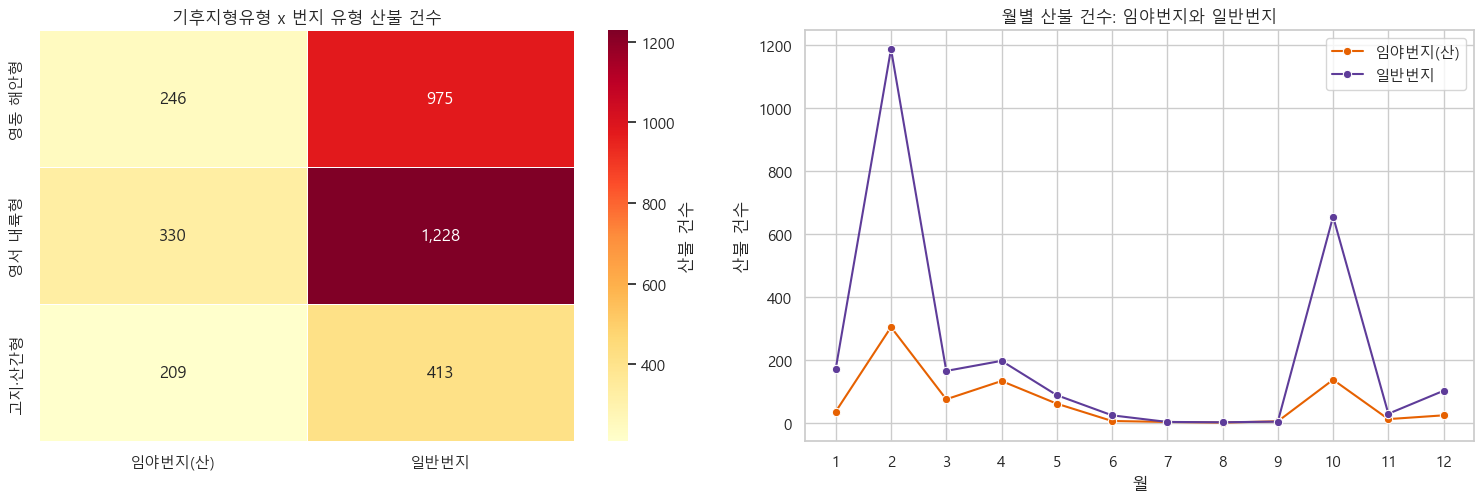

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

count_mat = (
    fire_weather.pivot_table(
        index="기후지형유형",
        columns="addr_type",
        values="fire_id",
        aggfunc="count",
        fill_value=0,
        observed=False,
    )
    .reindex(index=TYPE_ORDER, columns=ADDR_ORDER)
)
sns.heatmap(
    count_mat,
    annot=True,
    fmt=",.0f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "산불 건수"},
    ax=axes[0],
)
axes[0].set_title("기후지형유형 x 번지 유형 산불 건수")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

month_addr = (
    fire_weather.groupby(["월", "addr_type"], observed=False)
    .size()
    .rename("산불건수")
    .reset_index()
)
sns.lineplot(
    data=month_addr,
    x="월",
    y="산불건수",
    hue="addr_type",
    hue_order=ADDR_ORDER,
    palette=ADDR_PALETTE,
    marker="o",
    ax=axes[1],
)
axes[1].set_title("월별 산불 건수: 임야번지와 일반번지")
axes[1].set_xticks(range(1, 13))
axes[1].set_xlabel("월")
axes[1].set_ylabel("산불 건수")
axes[1].legend(title="")

savefig_show()


## 2. 산불 발생 시점의 기후지형유형별 기상 분포와 검정

이 단계는 산불이 발생한 시점만 놓고 세 기후지형유형의 발화 기상 조건이 같은지 확인한다.
검정은 Kruskal-Wallis를 기본으로 하고, 효과크기는 epsilon squared를 함께 본다.


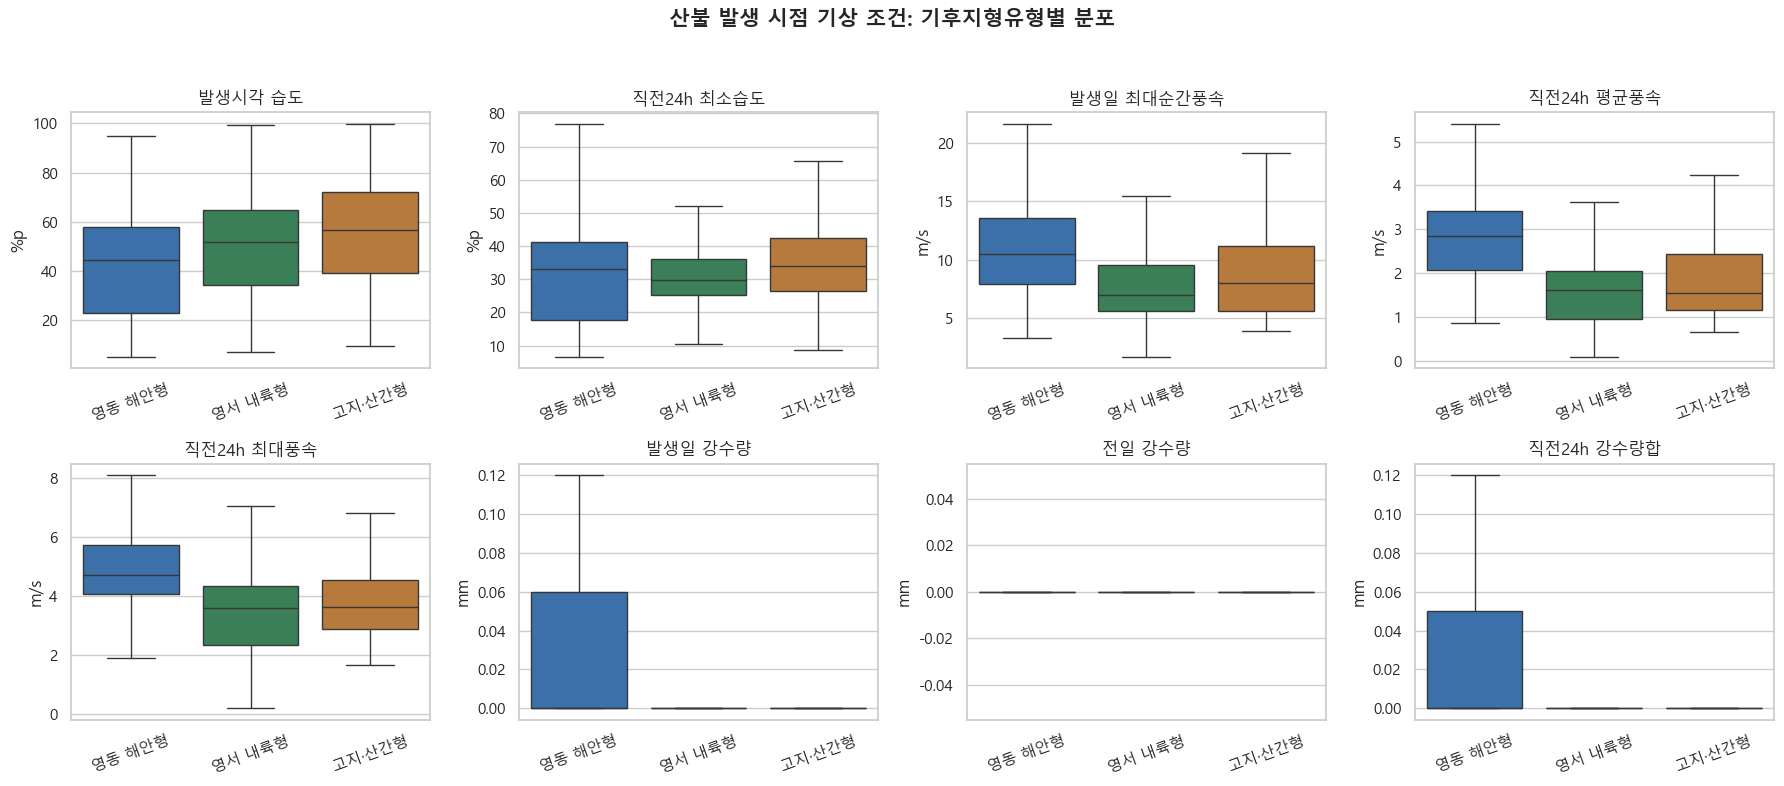

### Kruskal-Wallis 검정 요약

,변수,분류,유효표본수,epsilon2,p,FDR
3,직전24h 평균풍속,풍속,3399,0.323,2.77e-239,2.22e-238
2,발생일 최대순간풍속,풍속,3401,0.192,6.52e-143,2.61e-142
4,직전24h 최대풍속,풍속,3399,0.192,1.18e-142,3.15e-142
0,발생시각 습도,습도,3401,0.051,4.5e-39,9.01e-39
7,직전24h 강수량합,강수,3399,0.047,9.9e-36,1.58e-35
6,전일 강수량,강수,3399,0.033,1.59e-25,2.12e-25
1,직전24h 최소습도,습도,3399,0.018,2.71e-14,3.1e-14
5,발생일 강수량,강수,3401,0.011,4.02e-09,4.02e-09


In [4]:
FIRE_SPECS = [
    {"label": "발생시각 습도", "col": "발생시각_습도_pct", "unit": "%p", "risk_direction": -1, "family": "습도"},
    {"label": "직전24h 최소습도", "col": "발생시각_직전24h_최소습도_pct", "unit": "%p", "risk_direction": -1, "family": "습도"},
    {"label": "발생일 최대순간풍속", "col": "발생일_최대순간풍속_m_s", "unit": "m/s", "risk_direction": 1, "family": "풍속"},
    {"label": "직전24h 평균풍속", "col": "발생시각_직전24h_평균풍속_m_s", "unit": "m/s", "risk_direction": 1, "family": "풍속"},
    {"label": "직전24h 최대풍속", "col": "발생시각_직전24h_최대풍속_m_s", "unit": "m/s", "risk_direction": 1, "family": "풍속"},
    {"label": "발생일 강수량", "col": "발생일_강수량_mm", "unit": "mm", "risk_direction": -1, "family": "강수"},
    {"label": "전일 강수량", "col": "전일_강수량_mm", "unit": "mm", "risk_direction": -1, "family": "강수"},
    {"label": "직전24h 강수량합", "col": "발생시각_직전24h_강수량합_mm", "unit": "mm", "risk_direction": -1, "family": "강수"},
]


def kruskal_by_group(df, specs, group_col, group_order, analysis_name):
    rows = []
    for spec in specs:
        groups = [
            pd.to_numeric(df.loc[df[group_col] == g, spec["col"]], errors="coerce").dropna()
            for g in group_order
        ]
        valid_groups = [g for g in groups if len(g) >= 2]
        if len(valid_groups) < 2:
            continue
        h, p = stats.kruskal(*valid_groups)
        n = sum(len(g) for g in valid_groups)
        k = len(valid_groups)
        eps2 = max((h - k + 1) / (n - k), 0) if n > k else np.nan
        rows.append(
            {
                "분석": analysis_name,
                "변수": spec["label"],
                "분류": spec["family"],
                "H": h,
                "p": p,
                "epsilon2": eps2,
                "유효표본수": n,
            }
        )
    out = pd.DataFrame(rows)
    if not out.empty:
        out["FDR"] = fdr_values(out["p"]).values
    return out


def pairwise_group_tests(df, specs, group_col, group_order, analysis_name):
    rows = []
    for spec in specs:
        for a_name, b_name in combinations(group_order, 2):
            a = pd.to_numeric(df.loc[df[group_col] == a_name, spec["col"]], errors="coerce").dropna()
            b = pd.to_numeric(df.loc[df[group_col] == b_name, spec["col"]], errors="coerce").dropna()
            if len(a) < 2 or len(b) < 2:
                continue
            rows.append(
                {
                    "분석": analysis_name,
                    "변수": spec["label"],
                    "비교": f"{a_name} - {b_name}",
                    "A_n": len(a),
                    "B_n": len(b),
                    "A_평균": a.mean(),
                    "B_평균": b.mean(),
                    "평균차": a.mean() - b.mean(),
                    "Cohen_d": cohen_d(a, b),
                    "Cliffs_delta": cliffs_delta(a, b),
                    "MannWhitney_p": stats.mannwhitneyu(a, b, alternative="two-sided").pvalue,
                }
            )
    out = pd.DataFrame(rows)
    if not out.empty:
        out["MannWhitney_FDR"] = fdr_values(out["MannWhitney_p"]).values
    return out


type_kruskal = kruskal_by_group(fire_weather, FIRE_SPECS, "기후지형유형", TYPE_ORDER, "산불 시점")
type_pairwise = pairwise_group_tests(fire_weather, FIRE_SPECS, "기후지형유형", TYPE_ORDER, "산불 시점")

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, spec in zip(axes.ravel(), FIRE_SPECS):
    sns.boxplot(
        data=fire_weather,
        x="기후지형유형",
        y=spec["col"],
        order=TYPE_ORDER,
        palette=TYPE_PALETTE,
        showfliers=False,
        ax=ax,
    )
    ax.set_title(spec["label"])
    ax.set_xlabel("")
    ax.set_ylabel(spec["unit"])
    ax.tick_params(axis="x", rotation=20)
fig.suptitle("산불 발생 시점 기상 조건: 기후지형유형별 분포", fontsize=15, fontweight="bold")
savefig_show(rect=[0, 0, 1, 0.95])

display(Markdown("### Kruskal-Wallis 검정 요약"))
display(
    type_kruskal.sort_values("epsilon2", ascending=False)[
        ["변수", "분류", "유효표본수", "epsilon2", "p", "FDR"]
    ].style.format({"epsilon2": "{:.3f}", "p": "{:.3g}", "FDR": "{:.3g}"})
)


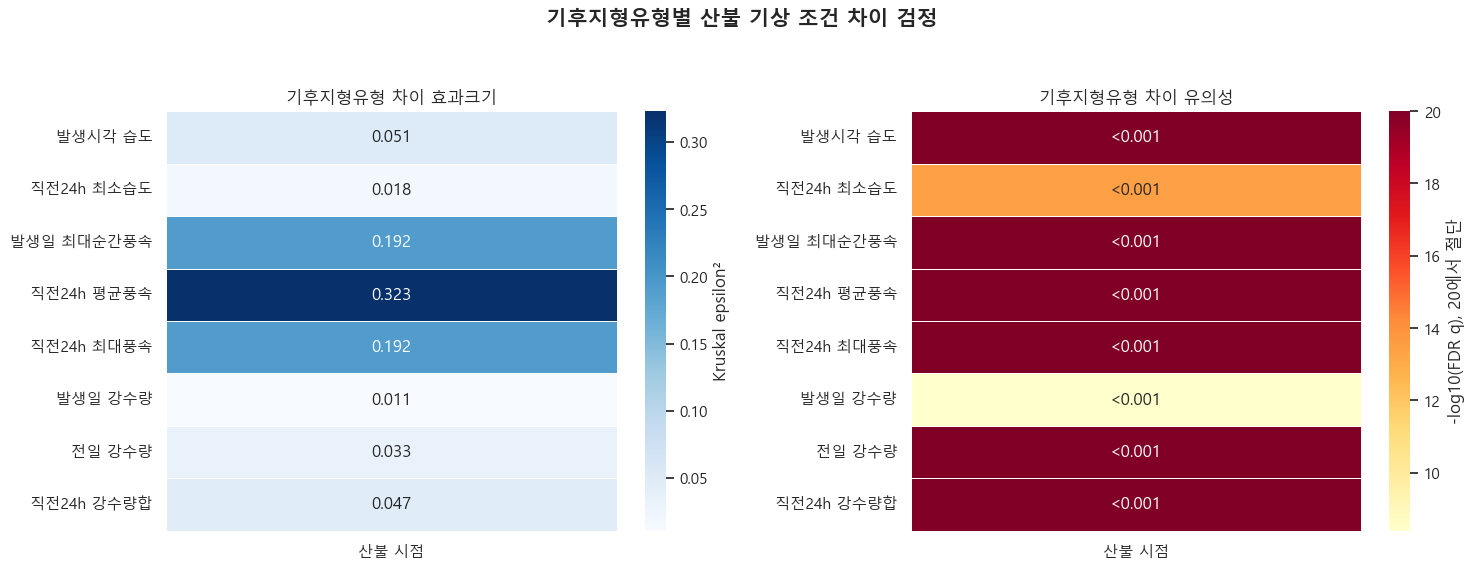

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

kw_effect = type_kruskal.pivot_table(index="변수", columns="분석", values="epsilon2", observed=False)
kw_effect = kw_effect.reindex([s["label"] for s in FIRE_SPECS])
sns.heatmap(
    kw_effect,
    cmap="Blues",
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    cbar_kws={"label": "Kruskal epsilon²"},
    ax=axes[0],
)
axes[0].set_title("기후지형유형 차이 효과크기")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

kw_fdr = type_kruskal.pivot_table(index="변수", columns="분석", values="FDR", observed=False)
kw_fdr = kw_fdr.reindex([s["label"] for s in FIRE_SPECS]).fillna(1).clip(lower=1e-300)
kw_neglog = (-np.log10(kw_fdr)).clip(upper=20)
annot = kw_fdr.map(format_p)
sns.heatmap(
    kw_neglog,
    cmap="YlOrRd",
    annot=annot,
    fmt="",
    linewidths=0.5,
    cbar_kws={"label": "-log10(FDR q), 20에서 절단"},
    ax=axes[1],
)
axes[1].set_title("기후지형유형 차이 유의성")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

fig.suptitle("기후지형유형별 산불 기상 조건 차이 검정", fontsize=15, fontweight="bold")
savefig_show(rect=[0, 0, 1, 0.94])


## 3. 같은 셀·월·시간대 매칭 대조군 대비 산불 기상 이상성

전체 비발생 분포와 비교하면 계절, 지리, 시간대 효과가 섞인다.
따라서 각 산불에 대해 같은 기상셀, 같은 월, 같은 시간대에서 산불이 없었던 시점 최대 5개를 뽑아 매칭 대조군으로 사용한다.


In [6]:
def make_nonfire_sets(fire_cells, daily, hourly24):
    fire_hour_keys = set(zip(fire_cells["기상셀ID"], fire_cells["발생일시"]))
    fire_day_keys = set(zip(fire_cells["기상셀ID"], fire_cells["날짜"]))
    daily_nonfire = daily[~pd.MultiIndex.from_frame(daily[["기상셀ID", "날짜"]]).isin(fire_day_keys)].copy()
    hourly_nonfire = hourly24[~pd.MultiIndex.from_frame(hourly24[["기상셀ID", "일시"]]).isin(fire_hour_keys)].copy()
    return daily_nonfire, hourly_nonfire, fire_hour_keys, fire_day_keys


def build_matched_controls(fire_cells, daily, hourly24, fire_hour_keys, fire_day_keys):
    candidate = hourly24[
        ~pd.MultiIndex.from_frame(hourly24[["기상셀ID", "일시"]]).isin(fire_hour_keys)
        & ~pd.MultiIndex.from_frame(hourly24[["기상셀ID", "날짜"]]).isin(fire_day_keys)
    ][["기상셀ID", "일시", "날짜", "월", "시간"]].copy()

    pools = {
        key: frame.index.to_numpy()
        for key, frame in candidate.groupby(["기상셀ID", "월", "시간"], sort=False)
    }
    rng = np.random.default_rng(RANDOM_STATE)
    rows = []
    for row in fire_cells[["fire_id", "기상셀ID", "월_key", "시간_key"]].itertuples(index=False):
        key = (row.기상셀ID, row.월_key, row.시간_key)
        idx = pools.get(key, np.array([], dtype=int))
        if len(idx) == 0:
            continue
        pick = rng.choice(idx, size=min(5, len(idx)), replace=False)
        selected = candidate.loc[pick, ["기상셀ID", "일시", "날짜"]].copy()
        selected.insert(0, "fire_id", row.fire_id)
        rows.append(selected)

    controls = pd.concat(rows, ignore_index=True)
    controls = controls.merge(
        hourly24.add_prefix("대조시각_"),
        left_on=["기상셀ID", "일시"],
        right_on=["대조시각_기상셀ID", "대조시각_일시"],
        how="left",
    )
    controls = controls.merge(
        daily.add_prefix("대조일_"),
        left_on=["기상셀ID", "날짜"],
        right_on=["대조일_기상셀ID", "대조일_날짜"],
        how="left",
    )
    controls["전일"] = controls["날짜"] - pd.Timedelta(days=1)
    controls = controls.merge(
        daily.add_prefix("대조전일_"),
        left_on=["기상셀ID", "전일"],
        right_on=["대조전일_기상셀ID", "대조전일_날짜"],
        how="left",
    )
    return controls


MATCHED_SPECS = [
    {"label": "발생시각 습도", "fire_col": "발생시각_습도_pct", "control_col": "대조시각_습도_pct", "unit": "%p", "risk_direction": -1, "family": "습도"},
    {"label": "직전24h 최소습도", "fire_col": "발생시각_직전24h_최소습도_pct", "control_col": "대조시각_직전24h_최소습도_pct", "unit": "%p", "risk_direction": -1, "family": "습도"},
    {"label": "발생일 강수량", "fire_col": "발생일_강수량_mm", "control_col": "대조일_강수량_mm", "unit": "mm", "risk_direction": -1, "family": "강수"},
    {"label": "전일 강수량", "fire_col": "전일_강수량_mm", "control_col": "대조전일_강수량_mm", "unit": "mm", "risk_direction": -1, "family": "강수"},
    {"label": "직전24h 강수량합", "fire_col": "발생시각_직전24h_강수량합_mm", "control_col": "대조시각_직전24h_강수량합_mm", "unit": "mm", "risk_direction": -1, "family": "강수"},
    {"label": "발생일 최대순간풍속", "fire_col": "발생일_최대순간풍속_m_s", "control_col": "대조일_최대순간풍속_m_s", "unit": "m/s", "risk_direction": 1, "family": "풍속"},
    {"label": "발생시각 풍속", "fire_col": "발생시각_풍속_m_s", "control_col": "대조시각_풍속_m_s", "unit": "m/s", "risk_direction": 1, "family": "풍속"},
    {"label": "직전24h 평균풍속", "fire_col": "발생시각_직전24h_평균풍속_m_s", "control_col": "대조시각_직전24h_평균풍속_m_s", "unit": "m/s", "risk_direction": 1, "family": "풍속"},
    {"label": "직전24h 최대풍속", "fire_col": "발생시각_직전24h_최대풍속_m_s", "control_col": "대조시각_직전24h_최대풍속_m_s", "unit": "m/s", "risk_direction": 1, "family": "풍속"},
]


def build_delta_tables(fire_df, controls, specs):
    meta_cols = ["fire_id", "기후권역", "기후지형유형", "addr_type", "월", "시간", "발생원인명"]
    meta = fire_df[meta_cols].drop_duplicates("fire_id").set_index("fire_id")
    wide = meta.copy()
    long_rows = []
    summary_rows = []

    for spec in specs:
        ctrl_mean = controls.groupby("fire_id")[spec["control_col"]].mean()
        fire_vals = pd.to_numeric(fire_df.set_index("fire_id")[spec["fire_col"]], errors="coerce")
        both = pd.concat([fire_vals.rename("산불"), ctrl_mean.rename("대조군평균")], axis=1).dropna()
        both = both.join(meta, how="left")
        diff = both["산불"] - both["대조군평균"]
        risk_delta = spec["risk_direction"] * diff
        wide.loc[both.index, f"raw::{spec['label']}"] = diff
        wide.loc[both.index, f"risk::{spec['label']}"] = risk_delta

        try:
            wilcoxon_p = stats.wilcoxon(diff).pvalue
        except ValueError:
            wilcoxon_p = np.nan
        ci_low, ci_high = mean_ci(diff)
        summary_rows.append(
            {
                "조건": spec["label"],
                "분류": spec["family"],
                "단위": spec["unit"],
                "n": len(diff),
                "산불평균": both["산불"].mean(),
                "대조군평균": both["대조군평균"].mean(),
                "평균차": diff.mean(),
                "CI_low": ci_low,
                "CI_high": ci_high,
                "위험방향_평균차": risk_delta.mean(),
                "Cohen_dz": diff.mean() / diff.std(ddof=1) if diff.std(ddof=1) else np.nan,
                "위험방향_dz": risk_delta.mean() / risk_delta.std(ddof=1) if risk_delta.std(ddof=1) else np.nan,
                "paired_t_p": stats.ttest_1samp(diff, 0, nan_policy="omit").pvalue,
                "Wilcoxon_p": wilcoxon_p,
            }
        )

        for fire_id, row in both.iterrows():
            long_rows.append(
                {
                    "fire_id": fire_id,
                    "조건": spec["label"],
                    "분류": spec["family"],
                    "단위": spec["unit"],
                    "산불": row["산불"],
                    "대조군평균": row["대조군평균"],
                    "차이": diff.loc[fire_id],
                    "위험방향_차이": risk_delta.loc[fire_id],
                    "기후권역": row["기후권역"],
                    "기후지형유형": row["기후지형유형"],
                    "addr_type": row["addr_type"],
                    "월": row["월"],
                    "시간": row["시간"],
                }
            )

    summary = pd.DataFrame(summary_rows)
    summary["paired_t_FDR"] = fdr_values(summary["paired_t_p"]).values
    summary["Wilcoxon_FDR"] = fdr_values(summary["Wilcoxon_p"]).values
    long = pd.DataFrame(long_rows)
    return wide.reset_index(), long, summary


daily_nonfire, hourly_nonfire, fire_hour_keys, fire_day_keys = make_nonfire_sets(fire_cells, daily, hourly24)
matched_controls = build_matched_controls(fire_cells, daily, hourly24, fire_hour_keys, fire_day_keys)
delta_wide, delta_long, paired_summary = build_delta_tables(fire_weather, matched_controls, MATCHED_SPECS)

assert matched_controls["fire_id"].nunique() == len(fire_cells)
assert matched_controls.groupby("fire_id").size().between(1, 5).all()

display(Markdown(
    f'''### 매칭 대조군 구성
- 전체 비발생 일단위: **{len(daily_nonfire):,}행**
- 전체 비발생 시간단위: **{len(hourly_nonfire):,}행**
- 매칭 비발생: **{len(matched_controls):,}행**
- 산불 1건당 매칭 비발생 수: **{matched_controls.groupby("fire_id").size().mean():.1f}개**
'''
))

display(
    paired_summary.sort_values("위험방향_dz", ascending=False)[
        ["조건", "분류", "n", "산불평균", "대조군평균", "평균차", "위험방향_dz", "Wilcoxon_FDR"]
    ].style.format(
        {
            "산불평균": "{:.2f}",
            "대조군평균": "{:.2f}",
            "평균차": "{:.2f}",
            "위험방향_dz": "{:.3f}",
            "Wilcoxon_FDR": "{:.3g}",
        }
    )
)


### 매칭 대조군 구성
- 전체 비발생 일단위: **66,332행**
- 전체 비발생 시간단위: **1,612,898행**
- 매칭 비발생: **17,005행**
- 산불 1건당 매칭 비발생 수: **5.0개**


,조건,분류,n,산불평균,대조군평균,평균차,위험방향_dz,Wilcoxon_FDR
1,직전24h 최소습도,습도,3399,32.92,41.69,-8.77,0.675,5.75e-270
0,발생시각 습도,습도,3401,49.69,56.87,-7.18,0.364,9.1e-98
2,발생일 강수량,강수,3401,0.49,1.59,-1.10,0.258,6.18e-235
3,전일 강수량,강수,3399,0.40,1.59,-1.19,0.257,5.37e-248
5,발생일 최대순간풍속,풍속,3401,8.98,8.32,0.66,0.214,4.21e-21
4,직전24h 강수량합,강수,3399,0.39,1.62,-1.24,0.200,2.41e-292
7,직전24h 평균풍속,풍속,3399,2.12,1.95,0.17,0.194,2.52e-15
8,직전24h 최대풍속,풍속,3399,4.12,3.89,0.24,0.177,1.52e-21
6,발생시각 풍속,풍속,3401,2.42,2.33,0.09,0.066,0.193


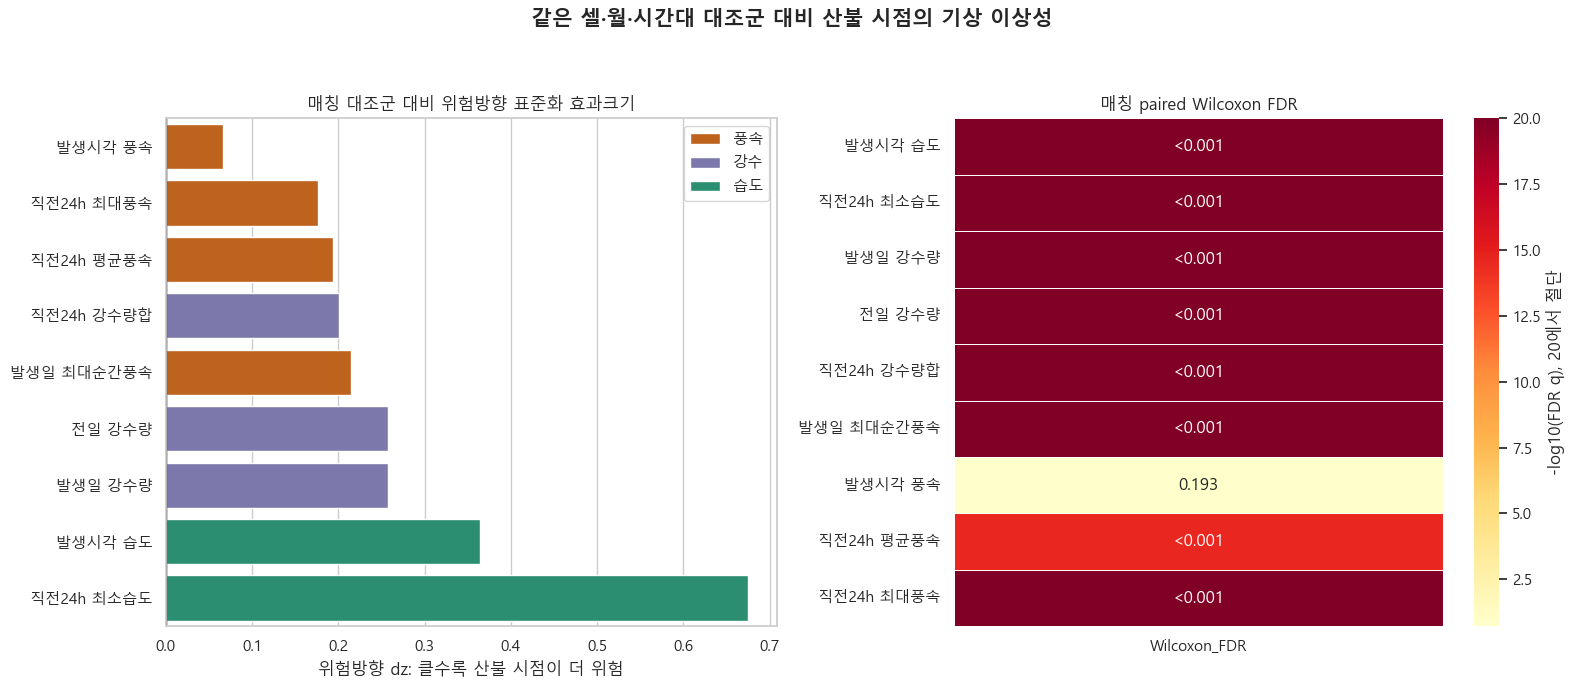

In [7]:
paired_plot = paired_summary.sort_values("위험방향_dz", ascending=True).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(
    data=paired_plot,
    y="조건",
    x="위험방향_dz",
    hue="분류",
    dodge=False,
    palette={"습도": "#1B9E77", "강수": "#7570B3", "풍속": "#D95F02"},
    ax=axes[0],
)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("매칭 대조군 대비 위험방향 표준화 효과크기")
axes[0].set_xlabel("위험방향 dz: 클수록 산불 시점이 더 위험")
axes[0].set_ylabel("")
axes[0].legend(title="")

sig_tbl = paired_summary.set_index("조건").reindex([s["label"] for s in MATCHED_SPECS])
fdr_mat = sig_tbl[["Wilcoxon_FDR"]].fillna(1).clip(lower=1e-300)
fdr_neglog = (-np.log10(fdr_mat)).clip(upper=20)
sns.heatmap(
    fdr_neglog,
    cmap="YlOrRd",
    annot=fdr_mat.map(format_p),
    fmt="",
    linewidths=0.5,
    cbar_kws={"label": "-log10(FDR q), 20에서 절단"},
    ax=axes[1],
)
axes[1].set_title("매칭 paired Wilcoxon FDR")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

fig.suptitle("같은 셀·월·시간대 대조군 대비 산불 시점의 기상 이상성", fontsize=15, fontweight="bold")
savefig_show(rect=[0, 0, 1, 0.94])


## 4. 기상 이상성의 집단별 이질성

전체 평균에서 산불 시점이 더 건조하고 강풍에 가깝더라도, 그 이상성의 크기가 모든 공간·기후 집단에서 같다고 볼 수는 없다.
여기서는 매칭 대조군 대비 차이값을 기후지형유형과 번지 유형별로 다시 검정한다.


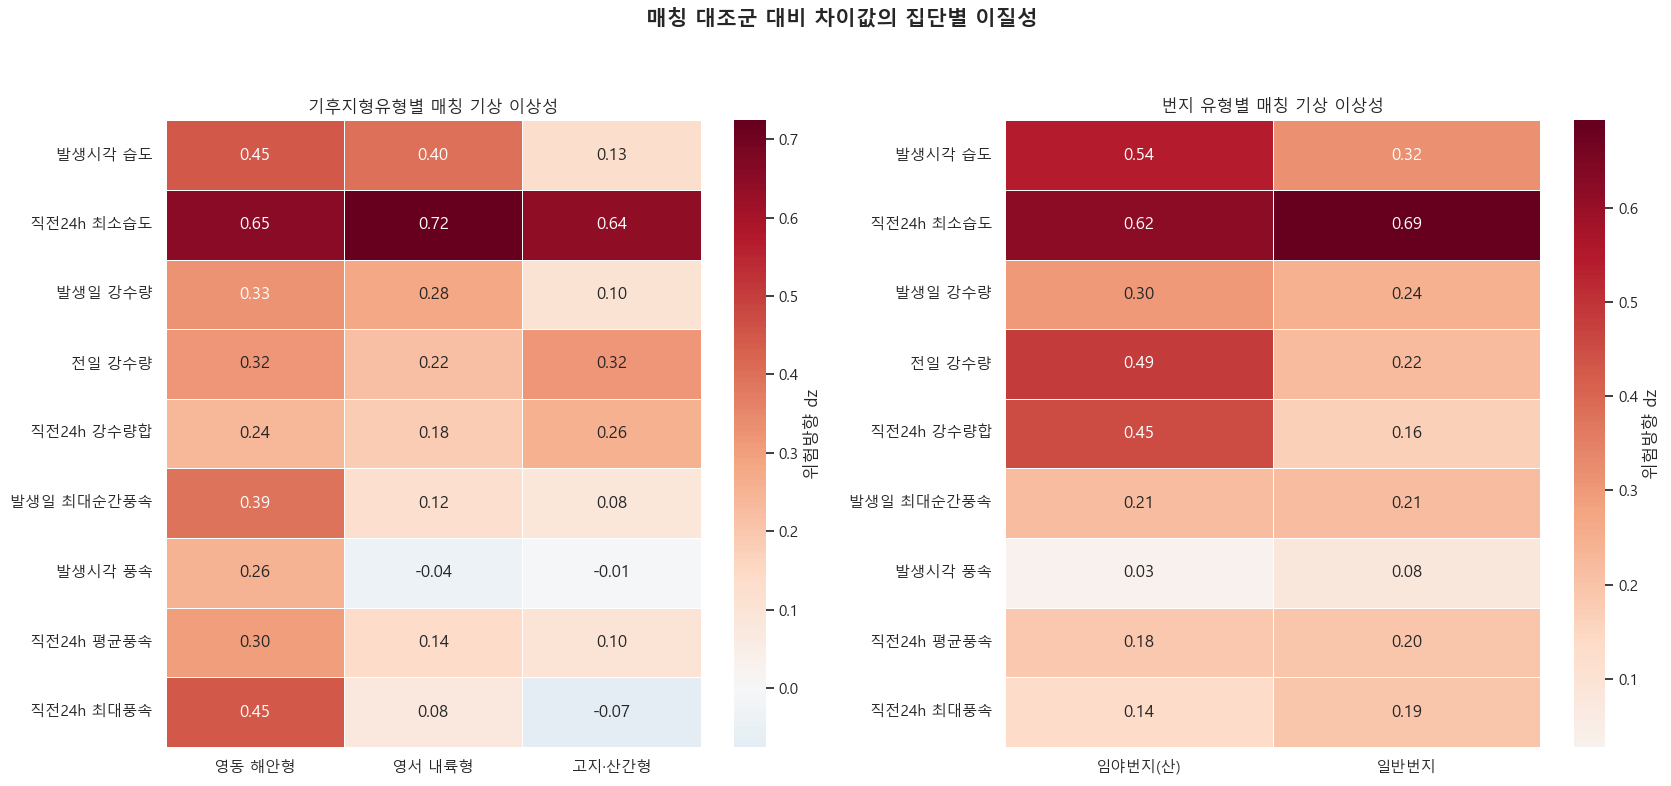

### 집단별 매칭 차이 검정 중 FDR < 0.05 결과

,분석축,집단,조건,n,평균차,위험방향_dz,Wilcoxon_FDR
28,addr_type,일반번지,발생시각 습도,2616,-6.35,0.316,3.01e-59
27,addr_type,임야번지(산),발생시각 습도,785,-9.94,0.544,1.32e-44
32,addr_type,일반번지,발생일 강수량,2616,-1.04,0.244,7.29e-176
31,addr_type,임야번지(산),발생일 강수량,785,-1.33,0.302,2.31e-60
38,addr_type,일반번지,발생일 최대순간풍속,2616,0.67,0.214,1.94e-16
37,addr_type,임야번지(산),발생일 최대순간풍속,785,0.62,0.213,4.46e-06
34,addr_type,일반번지,전일 강수량,2614,-1.11,0.222,2.26e-172
33,addr_type,임야번지(산),전일 강수량,785,-1.44,0.487,7.57e-79
36,addr_type,일반번지,직전24h 강수량합,2614,-1.10,0.163,4.72e-215
35,addr_type,임야번지(산),직전24h 강수량합,785,-1.70,0.452,4.27e-79


In [8]:
def subgroup_delta_tests(delta_wide, specs, group_col, group_order):
    rows = []
    for spec in specs:
        raw_col = f"raw::{spec['label']}"
        risk_col = f"risk::{spec['label']}"
        for group in group_order:
            part = delta_wide.loc[delta_wide[group_col] == group, [raw_col, risk_col]].dropna()
            if len(part) < 2:
                continue
            raw = part[raw_col]
            risk = part[risk_col]
            try:
                p_val = stats.wilcoxon(raw).pvalue
            except ValueError:
                p_val = np.nan
            rows.append(
                {
                    "분석축": group_col,
                    "집단": group,
                    "조건": spec["label"],
                    "분류": spec["family"],
                    "단위": spec["unit"],
                    "n": len(raw),
                    "평균차": raw.mean(),
                    "위험방향_평균차": risk.mean(),
                    "위험방향_dz": risk.mean() / risk.std(ddof=1) if risk.std(ddof=1) else np.nan,
                    "Wilcoxon_p": p_val,
                }
            )
    out = pd.DataFrame(rows)
    if not out.empty:
        out["Wilcoxon_FDR"] = fdr_values(out["Wilcoxon_p"]).values
    return out


climate_delta_tests = subgroup_delta_tests(delta_wide, MATCHED_SPECS, "기후지형유형", TYPE_ORDER)
addr_delta_tests = subgroup_delta_tests(delta_wide, MATCHED_SPECS, "addr_type", ADDR_ORDER)
subgroup_delta = pd.concat([climate_delta_tests, addr_delta_tests], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(17, 8))

climate_heat = (
    climate_delta_tests.pivot_table(index="조건", columns="집단", values="위험방향_dz", observed=False)
    .reindex(index=[s["label"] for s in MATCHED_SPECS], columns=TYPE_ORDER)
)
sns.heatmap(
    climate_heat,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "위험방향 dz"},
    ax=axes[0],
)
axes[0].set_title("기후지형유형별 매칭 기상 이상성")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

addr_heat = (
    addr_delta_tests.pivot_table(index="조건", columns="집단", values="위험방향_dz", observed=False)
    .reindex(index=[s["label"] for s in MATCHED_SPECS], columns=ADDR_ORDER)
)
sns.heatmap(
    addr_heat,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "위험방향 dz"},
    ax=axes[1],
)
axes[1].set_title("번지 유형별 매칭 기상 이상성")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

fig.suptitle("매칭 대조군 대비 차이값의 집단별 이질성", fontsize=15, fontweight="bold")
savefig_show(rect=[0, 0, 1, 0.94])

display(Markdown("### 집단별 매칭 차이 검정 중 FDR < 0.05 결과"))
display(
    subgroup_delta[subgroup_delta["Wilcoxon_FDR"] < 0.05]
    .sort_values(["분석축", "조건", "집단"])[
        ["분석축", "집단", "조건", "n", "평균차", "위험방향_dz", "Wilcoxon_FDR"]
    ]
    .style.format({"평균차": "{:.2f}", "위험방향_dz": "{:.3f}", "Wilcoxon_FDR": "{:.3g}"})
)


## 5. 임야번지와 일반번지의 발화 기상 임계치 비교

다음 융합 EDA는 지형, 토지피복, 인프라 접근성을 결합한다.
그 필요성을 먼저 확인하기 위해, 공간적 발화 영역의 간접 지표인 `임야번지(산)`와 `일반번지`만으로도 발화 당시 기상 조건이 달라지는지 검정한다.


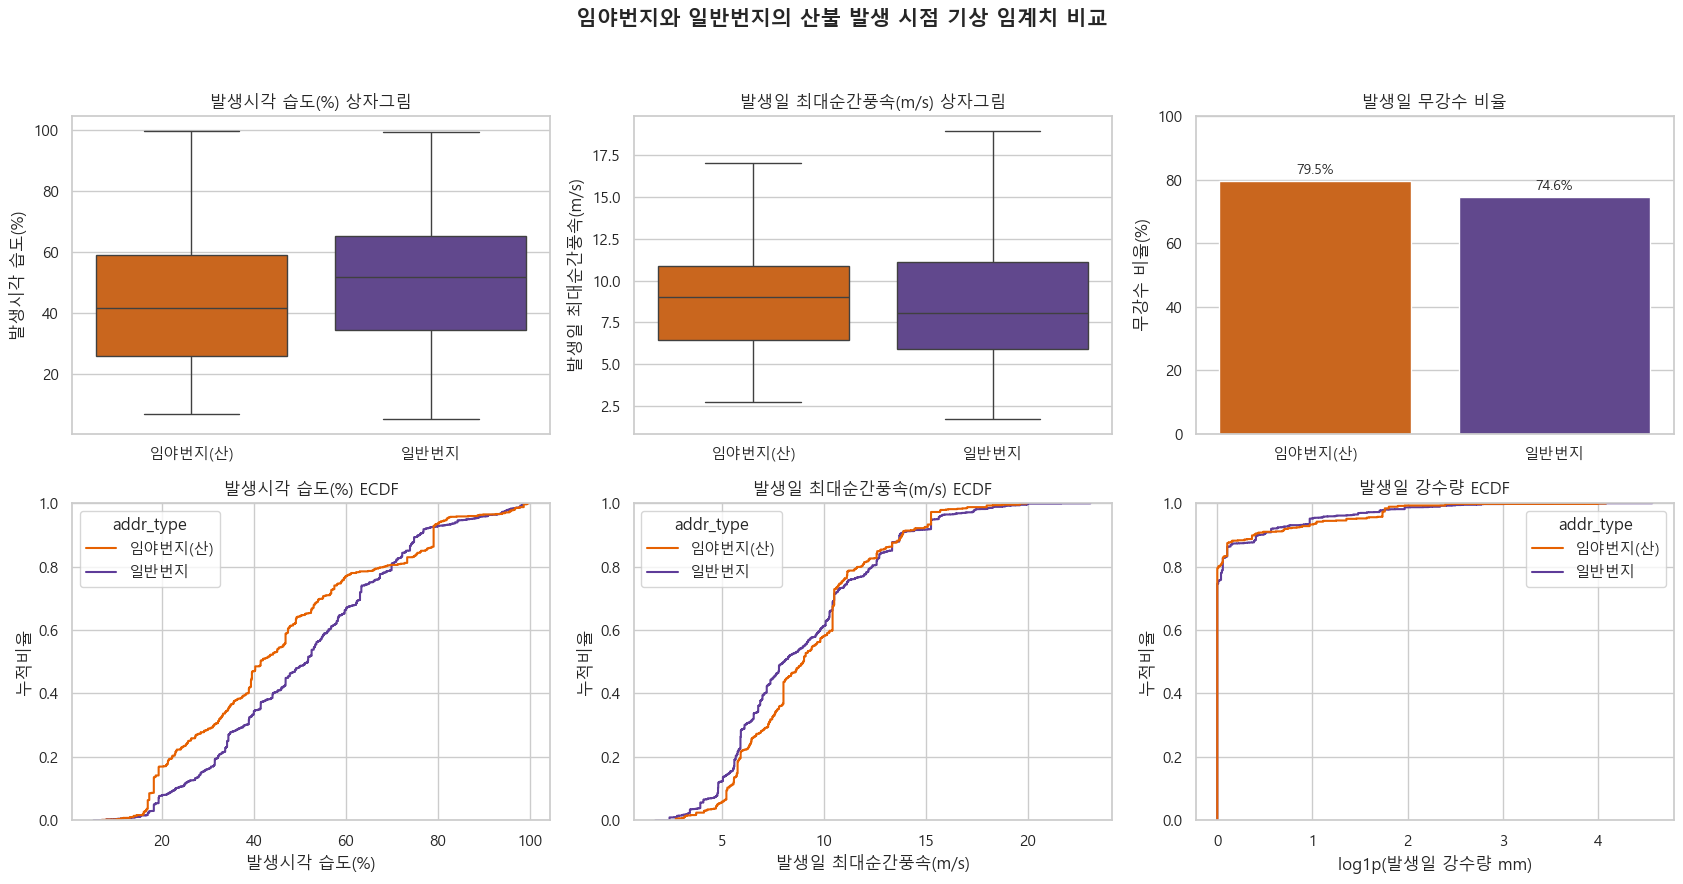

### 임야번지(산) - 일반번지 통계 검정

,변수,분류,A_n,B_n,A_평균,B_평균,평균차,Cohen_d,Cliffs_delta,MannWhitney_FDR
0,발생시각 습도,습도,785,2616,45.54,50.94,-5.40,-0.258,-0.159,7.61e-11
5,직전24h 강수량합,강수,785,2614,0.23,0.44,-0.21,-0.037,-0.059,0.000974
2,발생일 최대순간풍속,풍속,785,2616,9.21,8.91,0.30,0.083,0.075,0.00275
4,발생일 강수량,강수,785,2616,0.48,0.49,-0.01,-0.002,-0.041,0.0325
1,직전24h 최소습도,습도,785,2614,33.29,32.81,0.48,0.033,-0.050,0.0388
3,직전24h 평균풍속,풍속,785,2614,2.15,2.11,0.04,0.036,0.008,0.745


In [9]:
ADDR_SPECS = [
    {"label": "발생시각 습도", "col": "발생시각_습도_pct", "unit": "%p", "family": "습도"},
    {"label": "직전24h 최소습도", "col": "발생시각_직전24h_최소습도_pct", "unit": "%p", "family": "습도"},
    {"label": "발생일 최대순간풍속", "col": "발생일_최대순간풍속_m_s", "unit": "m/s", "family": "풍속"},
    {"label": "직전24h 평균풍속", "col": "발생시각_직전24h_평균풍속_m_s", "unit": "m/s", "family": "풍속"},
    {"label": "발생일 강수량", "col": "발생일_강수량_mm", "unit": "mm", "family": "강수"},
    {"label": "직전24h 강수량합", "col": "발생시각_직전24h_강수량합_mm", "unit": "mm", "family": "강수"},
]


def two_group_tests(df, specs, group_col, group_a, group_b, analysis_name):
    rows = []
    for spec in specs:
        a = pd.to_numeric(df.loc[df[group_col] == group_a, spec["col"]], errors="coerce").dropna()
        b = pd.to_numeric(df.loc[df[group_col] == group_b, spec["col"]], errors="coerce").dropna()
        if len(a) < 2 or len(b) < 2:
            continue
        rows.append(
            {
                "분석": analysis_name,
                "변수": spec["label"],
                "분류": spec["family"],
                "단위": spec["unit"],
                "A집단": group_a,
                "B집단": group_b,
                "A_n": len(a),
                "B_n": len(b),
                "A_평균": a.mean(),
                "B_평균": b.mean(),
                "A_중앙값": a.median(),
                "B_중앙값": b.median(),
                "평균차": a.mean() - b.mean(),
                "Cohen_d": cohen_d(a, b),
                "Cliffs_delta": cliffs_delta(a, b),
                "Welch_p": stats.ttest_ind(a, b, equal_var=False, nan_policy="omit").pvalue,
                "MannWhitney_p": stats.mannwhitneyu(a, b, alternative="two-sided").pvalue,
            }
        )
    out = pd.DataFrame(rows)
    if not out.empty:
        out["Welch_FDR"] = fdr_values(out["Welch_p"]).values
        out["MannWhitney_FDR"] = fdr_values(out["MannWhitney_p"]).values
    return out


def dry_rate(values):
    values = pd.to_numeric(values, errors="coerce").dropna()
    if len(values) == 0:
        return np.nan
    return (values <= 0).mean() * 100


addr_stats = two_group_tests(fire_weather, ADDR_SPECS, "addr_type", "임야번지(산)", "일반번지", "산불 시점")

fig, axes = plt.subplots(2, 3, figsize=(17, 9))

standard_plot_specs = [
    ("발생시각_습도_pct", "발생시각 습도(%)"),
    ("발생일_최대순간풍속_m_s", "발생일 최대순간풍속(m/s)"),
]
for i, (col, label) in enumerate(standard_plot_specs):
    sns.boxplot(
        data=fire_weather,
        x="addr_type",
        y=col,
        order=ADDR_ORDER,
        palette=ADDR_PALETTE,
        showfliers=False,
        ax=axes[0, i],
    )
    axes[0, i].set_title(f"{label} 상자그림")
    axes[0, i].set_xlabel("")
    axes[0, i].set_ylabel(label)

    sns.ecdfplot(
        data=fire_weather,
        x=col,
        hue="addr_type",
        hue_order=ADDR_ORDER,
        palette=ADDR_PALETTE,
        ax=axes[1, i],
    )
    axes[1, i].set_title(f"{label} ECDF")
    axes[1, i].set_xlabel(label)
    axes[1, i].set_ylabel("누적비율")

dry_df = (
    fire_weather.groupby("addr_type", observed=False)["발생일_강수량_mm"]
    .apply(dry_rate)
    .reindex(ADDR_ORDER)
    .rename("무강수비율_pct")
    .reset_index()
)
sns.barplot(
    data=dry_df,
    x="addr_type",
    y="무강수비율_pct",
    order=ADDR_ORDER,
    palette=ADDR_PALETTE,
    ax=axes[0, 2],
)
axes[0, 2].set_title("발생일 무강수 비율")
axes[0, 2].set_xlabel("")
axes[0, 2].set_ylabel("무강수 비율(%)")
axes[0, 2].set_ylim(0, 100)
for patch in axes[0, 2].patches:
    height = patch.get_height()
    axes[0, 2].annotate(
        f"{height:.1f}%",
        (patch.get_x() + patch.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 3),
        textcoords="offset points",
    )

rain_plot = fire_weather.copy()
rain_plot["발생일_강수량_log1p"] = np.log1p(pd.to_numeric(rain_plot["발생일_강수량_mm"], errors="coerce"))
sns.ecdfplot(
    data=rain_plot,
    x="발생일_강수량_log1p",
    hue="addr_type",
    hue_order=ADDR_ORDER,
    palette=ADDR_PALETTE,
    ax=axes[1, 2],
)
axes[1, 2].set_title("발생일 강수량 ECDF")
axes[1, 2].set_xlabel("log1p(발생일 강수량 mm)")
axes[1, 2].set_ylabel("누적비율")

fig.suptitle("임야번지와 일반번지의 산불 발생 시점 기상 임계치 비교", fontsize=15, fontweight="bold")
savefig_show(rect=[0, 0, 1, 0.95])

display(Markdown("### 임야번지(산) - 일반번지 통계 검정"))
display(
    addr_stats.sort_values("MannWhitney_FDR")[
        ["변수", "분류", "A_n", "B_n", "A_평균", "B_평균", "평균차", "Cohen_d", "Cliffs_delta", "MannWhitney_FDR"]
    ].style.format(
        {
            "A_평균": "{:.2f}",
            "B_평균": "{:.2f}",
            "평균차": "{:.2f}",
            "Cohen_d": "{:.3f}",
            "Cliffs_delta": "{:.3f}",
            "MannWhitney_FDR": "{:.3g}",
        }
    )
)


## 6. 기후지형유형 x 번지 유형의 교차 임계치

기후지형유형은 광역적인 기상·지형 배경을, 번지 유형은 실제 발화 공간의 성격을 간접적으로 나타낸다.
두 축을 교차하면 다음 융합 EDA에서 지형·토지피복·접근성 변수를 함께 봐야 하는 이유를 더 직접적으로 확인할 수 있다.

단, 강수량은 산불 발생 시점에서 0mm가 매우 많아 중앙값 heatmap이 대부분 0으로 눌린다.
따라서 강수 변수는 중앙값 대신 `무강수 비율(%)`로 시각화해, 건조 상태의 빈도 차이를 직접 확인한다.


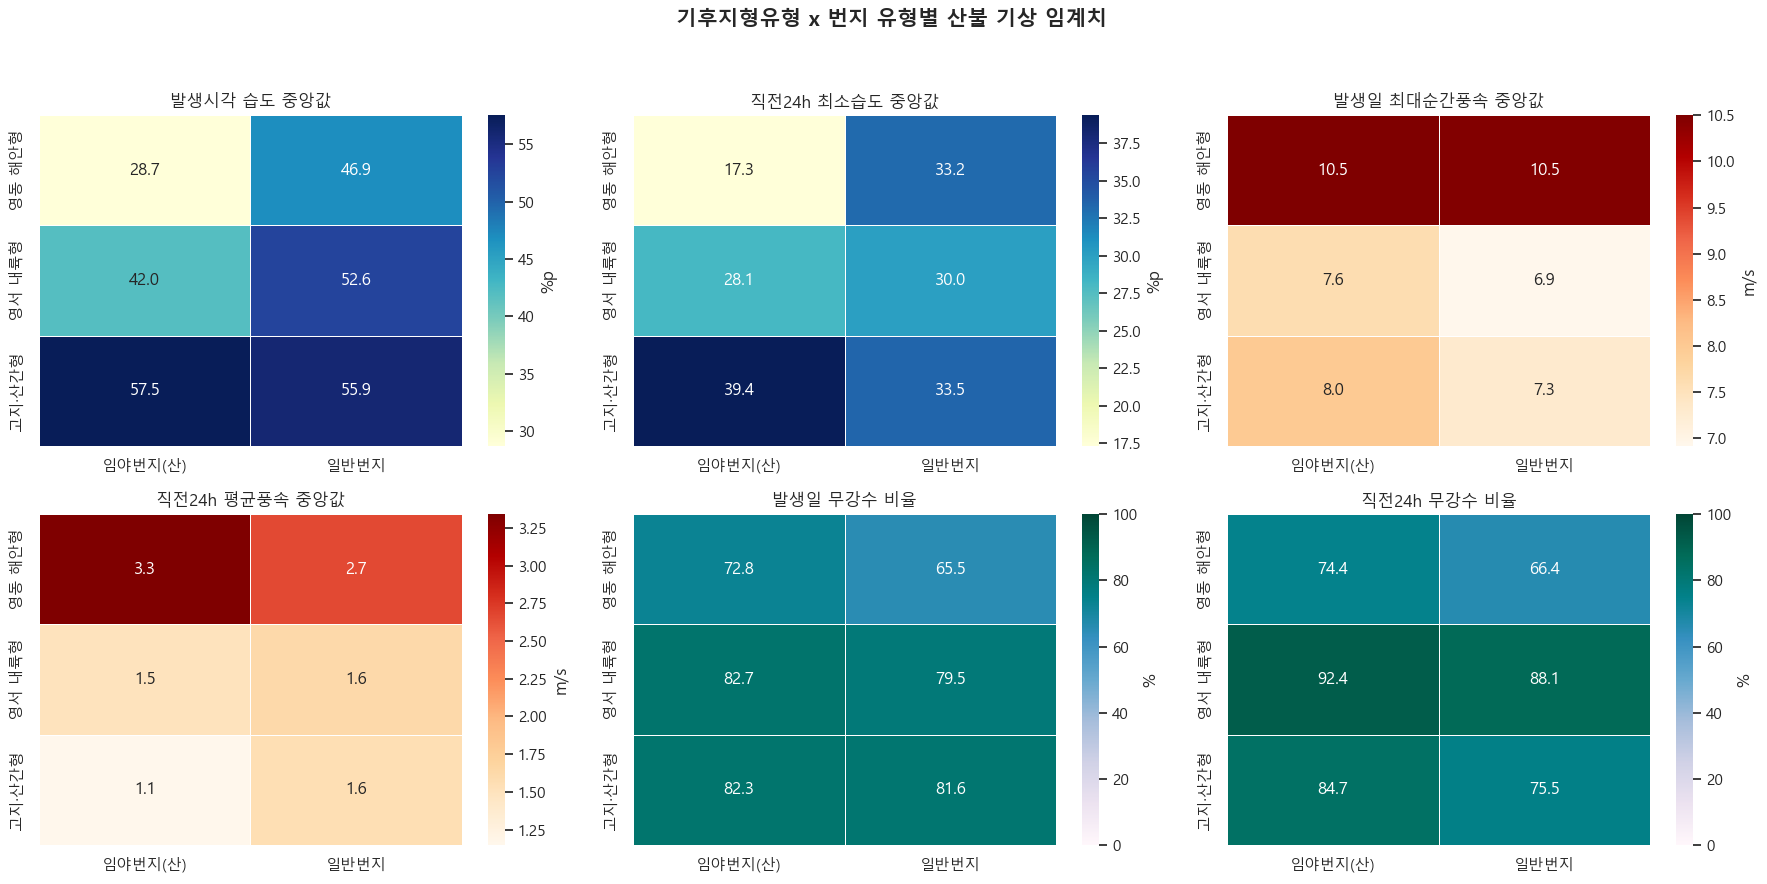

### 6개 교차 집단 Kruskal-Wallis 검정

,변수,분류,유효표본수,epsilon2,FDR
3,직전24h 평균풍속,풍속,3399,0.332,1.29e-241
2,발생일 최대순간풍속,풍속,3401,0.197,4.36e-143
0,발생시각 습도,습도,3401,0.083,2.22e-59
1,직전24h 최소습도,습도,3399,0.055,1.43e-39
5,직전24h 강수량합,강수,3399,0.051,3.82e-36
4,발생일 강수량,강수,3401,0.011,3.6e-08


In [10]:
fire_weather = fire_weather.copy()
fire_weather["유형_번지"] = fire_weather["기후지형유형"].astype(str) + " | " + fire_weather["addr_type"].astype(str)
INTERACTION_ORDER = [f"{t} | {a}" for t in TYPE_ORDER for a in ADDR_ORDER]

interaction_kruskal = kruskal_by_group(fire_weather, ADDR_SPECS, "유형_번지", INTERACTION_ORDER, "기후지형유형x번지")

HEATMAP_SPECS = [
    {"label": "발생시각 습도", "col": "발생시각_습도_pct", "unit": "%p", "family": "습도", "metric": "median", "metric_label": "중앙값"},
    {"label": "직전24h 최소습도", "col": "발생시각_직전24h_최소습도_pct", "unit": "%p", "family": "습도", "metric": "median", "metric_label": "중앙값"},
    {"label": "발생일 최대순간풍속", "col": "발생일_최대순간풍속_m_s", "unit": "m/s", "family": "풍속", "metric": "median", "metric_label": "중앙값"},
    {"label": "직전24h 평균풍속", "col": "발생시각_직전24h_평균풍속_m_s", "unit": "m/s", "family": "풍속", "metric": "median", "metric_label": "중앙값"},
    {"label": "발생일 무강수 비율", "col": "발생일_강수량_mm", "unit": "%", "family": "강수", "metric": "dry_rate", "metric_label": "무강수 비율"},
    {"label": "직전24h 무강수 비율", "col": "발생시각_직전24h_강수량합_mm", "unit": "%", "family": "강수", "metric": "dry_rate", "metric_label": "무강수 비율"},
]


def interaction_matrix(df, spec):
    if spec["metric"] == "median":
        mat = df.pivot_table(
            index="기후지형유형",
            columns="addr_type",
            values=spec["col"],
            aggfunc="median",
            observed=False,
        )
    elif spec["metric"] == "dry_rate":
        mat = df.pivot_table(
            index="기후지형유형",
            columns="addr_type",
            values=spec["col"],
            aggfunc=dry_rate,
            observed=False,
        )
    else:
        raise ValueError(spec["metric"])
    return mat.reindex(index=TYPE_ORDER, columns=ADDR_ORDER)


fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, spec in zip(axes.ravel(), HEATMAP_SPECS):
    mat = interaction_matrix(fire_weather, spec)
    if spec["family"] == "풍속":
        cmap = "OrRd"
        heatmap_kwargs = {}
    elif spec["family"] == "강수":
        cmap = "PuBuGn"
        heatmap_kwargs = {"vmin": 0, "vmax": 100}
    else:
        cmap = "YlGnBu"
        heatmap_kwargs = {}
    sns.heatmap(
        mat,
        cmap=cmap,
        annot=True,
        fmt=".1f",
        linewidths=0.5,
        cbar_kws={"label": spec["unit"]},
        ax=ax,
        **heatmap_kwargs,
    )
    title = spec["label"] if spec["metric"] == "dry_rate" else f"{spec['label']} {spec['metric_label']}"
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.suptitle("기후지형유형 x 번지 유형별 산불 기상 임계치", fontsize=15, fontweight="bold")
savefig_show(rect=[0, 0, 1, 0.95])

display(Markdown("### 6개 교차 집단 Kruskal-Wallis 검정"))
display(
    interaction_kruskal.sort_values("epsilon2", ascending=False)[
        ["변수", "분류", "유효표본수", "epsilon2", "FDR"]
    ].style.format({"epsilon2": "{:.3f}", "FDR": "{:.3g}"})
)


## 7. 다음 날씨-공간 융합 EDA로 넘길 근거

이 노트북의 역할은 기상 변수의 중요성을 다시 모델링하는 것이 아니라,
기상 신호가 공간적 발화 환경에 따라 달라진다는 점을 통계적으로 확인하는 것이다.
아래 셀은 앞선 검정 결과를 요약해 다음 융합 분석의 입력 논리로 정리한다.


In [11]:
def get_row(df, key_col, key):
    hit = df[df[key_col] == key]
    if hit.empty:
        return None
    return hit.iloc[0]


def signed_phrase(value, unit):
    if pd.isna(value):
        return "NA"
    direction = "높음" if value > 0 else "낮음"
    return f"{abs(value):.2f}{unit} {direction}"


humidity = get_row(paired_summary, "조건", "발생시각 습도")
min_humidity = get_row(paired_summary, "조건", "직전24h 최소습도")
gust = get_row(paired_summary, "조건", "발생일 최대순간풍속")
rain24 = get_row(paired_summary, "조건", "직전24h 강수량합")

addr_humidity = get_row(addr_stats, "변수", "발생시각 습도")
addr_gust = get_row(addr_stats, "변수", "발생일 최대순간풍속")
type_top = type_kruskal.sort_values("epsilon2", ascending=False).iloc[0]
interaction_top = interaction_kruskal.sort_values("epsilon2", ascending=False).iloc[0]
dry_by_addr = (
    fire_weather.groupby("addr_type", observed=False)["발생일_강수량_mm"]
    .apply(dry_rate)
    .reindex(ADDR_ORDER)
)

display(Markdown(
    f'''### 심화 EDA 핵심 해석

1. **매칭 대조군 대비 기상 이상성은 유지된다.**
   같은 기상셀·월·시간대의 비발생 시점과 비교해 산불 발생시각 습도는 평균 **{humidity["평균차"]:.2f}%p** 차이를 보였고(q={format_p(humidity["Wilcoxon_FDR"])}),
   직전 24시간 최소습도는 **{min_humidity["평균차"]:.2f}%p** 차이를 보였다(q={format_p(min_humidity["Wilcoxon_FDR"])}).
   발생일 최대순간풍속은 **{gust["평균차"]:.2f}m/s** 높고(q={format_p(gust["Wilcoxon_FDR"])}),
   직전 24시간 강수량합은 **{rain24["평균차"]:.2f}mm** 차이를 보였다(q={format_p(rain24["Wilcoxon_FDR"])}).

2. **기후지형유형에 따라 발화 기상 임계치가 다르다.**
   산불 시점 변수 중 기후지형유형 차이가 가장 큰 변수는 **{type_top["변수"]}**이며,
   Kruskal epsilon²는 **{type_top["epsilon2"]:.3f}**, FDR q는 **{format_p(type_top["FDR"])}**이다.
   이는 강원도 전체에 단일 기상 임계치를 적용하기 어렵다는 근거다.

3. **임야번지와 일반번지는 같은 산불이라도 요구되는 기상 조건이 다르다.**
   임야번지(산)는 일반번지 대비 발생시각 습도가 **{signed_phrase(addr_humidity["평균차"], "%p")}**,
   발생일 최대순간풍속이 **{signed_phrase(addr_gust["평균차"], "m/s")}** 나타났다.
   발생일 무강수 비율은 임야번지(산) **{dry_by_addr["임야번지(산)"]:.1f}%**, 일반번지 **{dry_by_addr["일반번지"]:.1f}%**이다.
   즉 발화 공간의 성격이 기상 임계치 해석에 직접 개입한다.

4. **기후지형유형 x 번지 유형 교차 집단 차이가 확인된다.**
   6개 교차 집단에서 가장 큰 차이를 보인 변수는 **{interaction_top["변수"]}**이며,
   epsilon²는 **{interaction_top["epsilon2"]:.3f}**, FDR q는 **{format_p(interaction_top["FDR"])}**이다.
   강수 변수는 중앙값이 대부분 0mm로 수렴해 착시가 생기므로, 교차 시각화에서는 `무강수 비율`로 반복 개선했다.
   따라서 다음 노트북에서는 단순 날씨 변수만이 아니라 고도, 경사도, 사면방향, TWI, 토지피복, 도로·임도·등산로·소방 인프라 접근성을 함께 결합해야 한다.

### 다음 분석으로 넘기는 변수 후보
- 기상: 발생시각 습도, 직전 24시간 최소습도, 발생일 최대순간풍속, 직전 24시간 평균/최대풍속, 발생일·전일·직전 24시간 강수량 및 무강수 여부
- 공간 프록시: 임야번지 여부, 기후지형유형
- 후속 융합 대상: DEM 고도, 경사도, 사면방향, TPI, TWI, 토지피복, 도로/임도/등산로 거리, 소방서/소방용수 거리
'''
))


### 심화 EDA 핵심 해석

1. **매칭 대조군 대비 기상 이상성은 유지된다.**
   같은 기상셀·월·시간대의 비발생 시점과 비교해 산불 발생시각 습도는 평균 **-7.18%p** 차이를 보였고(q=<0.001),
   직전 24시간 최소습도는 **-8.77%p** 차이를 보였다(q=<0.001).
   발생일 최대순간풍속은 **0.66m/s** 높고(q=<0.001),
   직전 24시간 강수량합은 **-1.24mm** 차이를 보였다(q=<0.001).

2. **기후지형유형에 따라 발화 기상 임계치가 다르다.**
   산불 시점 변수 중 기후지형유형 차이가 가장 큰 변수는 **직전24h 평균풍속**이며,
   Kruskal epsilon²는 **0.323**, FDR q는 **<0.001**이다.
   이는 강원도 전체에 단일 기상 임계치를 적용하기 어렵다는 근거다.

3. **임야번지와 일반번지는 같은 산불이라도 요구되는 기상 조건이 다르다.**
   임야번지(산)는 일반번지 대비 발생시각 습도가 **5.40%p 낮음**,
   발생일 최대순간풍속이 **0.30m/s 높음** 나타났다.
   발생일 무강수 비율은 임야번지(산) **79.5%**, 일반번지 **74.6%**이다.
   즉 발화 공간의 성격이 기상 임계치 해석에 직접 개입한다.

4. **기후지형유형 x 번지 유형 교차 집단 차이가 확인된다.**
   6개 교차 집단에서 가장 큰 차이를 보인 변수는 **직전24h 평균풍속**이며,
   epsilon²는 **0.332**, FDR q는 **<0.001**이다.
   강수 변수는 중앙값이 대부분 0mm로 수렴해 착시가 생기므로, 교차 시각화에서는 `무강수 비율`로 반복 개선했다.
   따라서 다음 노트북에서는 단순 날씨 변수만이 아니라 고도, 경사도, 사면방향, TWI, 토지피복, 도로·임도·등산로·소방 인프라 접근성을 함께 결합해야 한다.

### 다음 분석으로 넘기는 변수 후보
- 기상: 발생시각 습도, 직전 24시간 최소습도, 발생일 최대순간풍속, 직전 24시간 평균/최대풍속, 발생일·전일·직전 24시간 강수량 및 무강수 여부
- 공간 프록시: 임야번지 여부, 기후지형유형
- 후속 융합 대상: DEM 고도, 경사도, 사면방향, TPI, TWI, 토지피복, 도로/임도/등산로 거리, 소방서/소방용수 거리
